# Gemstone Classification

In [1]:

import os
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:

# CONFIG
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 200

DATASET_DIR = r"F:\FYP\code\dataset\GemStone"
MODEL_PATH = "gem_Classification_Model.h5"
CLASS_MAP_PATH = "gem_stones_classes.json"


In [3]:
import os
import shutil
import random

TRAIN_DIR  = os.path.join(DATASET_DIR, "train")
TEST_DIR   = os.path.join(DATASET_DIR, "test")

SPLIT_RATIO = 0.8  # 80% train, 20% test

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(class_path):
        continue
    if class_name in ["train", "test"]:
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * SPLIT_RATIO)

    train_images = images[:split_index]
    test_images  = images[split_index:]

    os.makedirs(os.path.join(TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TRAIN_DIR, class_name, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(TEST_DIR, class_name, img)
        )

print("✅ Dataset split completed")


✅ Dataset split completed


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    r"F:\FYP\code\dataset\GemStone\train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    r"F:\FYP\code\dataset\GemStone\test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle = False
)


Found 3189 images belonging to 87 classes.
Found 1629 images belonging to 87 classes.


In [5]:

# Save class names
class_names = train_gen.class_indices
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(class_names, f)

print("Classes:", class_names)


Classes: {'Alexandrite': 0, 'Almandine': 1, 'Amazonite': 2, 'Amber': 3, 'Amethyst': 4, 'Ametrine': 5, 'Andalusite': 6, 'Andradite': 7, 'Aquamarine': 8, 'Aventurine Green': 9, 'Aventurine Yellow': 10, 'Benitoite': 11, 'Beryl Golden': 12, 'Bixbite': 13, 'Bloodstone': 14, 'Blue Lace Agate': 15, 'Carnelian': 16, 'Cats Eye': 17, 'Chalcedony': 18, 'Chalcedony Blue': 19, 'Chrome Diopside': 20, 'Chrysoberyl': 21, 'Chrysocolla': 22, 'Chrysoprase': 23, 'Citrine': 24, 'Coral': 25, 'Danburite': 26, 'Diamond': 27, 'Diaspore': 28, 'Dumortierite': 29, 'Emerald': 30, 'Fluorite': 31, 'Garnet Red': 32, 'Goshenite': 33, 'Grossular': 34, 'Hessonite': 35, 'Hiddenite': 36, 'Iolite': 37, 'Jade': 38, 'Jasper': 39, 'Kunzite': 40, 'Kyanite': 41, 'Labradorite': 42, 'Lapis Lazuli': 43, 'Larimar': 44, 'Malachite': 45, 'Moonstone': 46, 'Morganite': 47, 'Onyx Black': 48, 'Onyx Green': 49, 'Onyx Red': 50, 'Opal': 51, 'Pearl': 52, 'Peridot': 53, 'Prehnite': 54, 'Pyrite': 55, 'Pyrope': 56, 'Quartz Beer': 57, 'Quartz Le

In [6]:

# Model
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 87)             │        22,359 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,538,391 (24.94 MB)

 Trainable params: 6,538,391 (24.94 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:

# Train
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen
)


Epoch 1/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 594ms/step - accuracy: 0.0637 - loss: 4.0789 - val_accuracy: 0.1835 - val_loss: 3.1685
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 338ms/step - accuracy: 0.1860 - loss: 3.0486 - val_accuracy: 0.3401 - val_loss: 2.3332
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 373ms/step - accuracy: 0.2775 - loss: 2.5163 - val_accuracy: 0.4524 - val_loss: 1.9026
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 364ms/step - accuracy: 0.3333 - loss: 2.2686 - val_accuracy: 0.5193 - val_loss: 1.5521
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 345ms/step - accuracy: 0.3866 - loss: 2.0300 - val_accuracy: 0.5709 - val_loss: 1.4063
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.4378 - loss: 1.8041 - val_accuracy: 0.6489 - val_loss: 1.1394
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 385ms/step - accuracy: 0.4788 - loss: 1.6864 - val_accuracy: 0.6372 - val_loss: 1.1642
Epoch 8/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 365ms/step - accuracy: 0.5102 -

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step

✅ Accuracy: 99.14%


<Figure size 2000x2000 with 0 Axes>

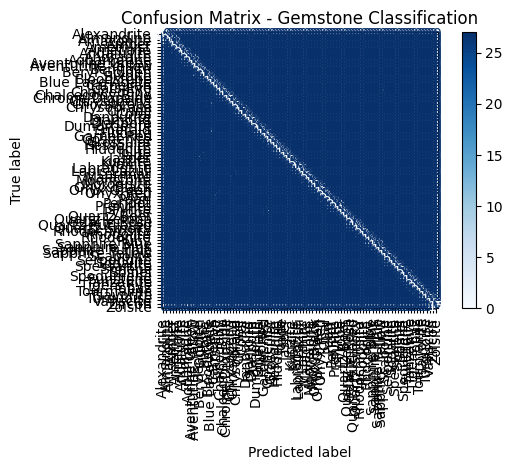


📊 Classification Report:

                   precision    recall  f1-score   support

      Alexandrite       1.00      1.00      1.00        21
        Almandine       1.00      1.00      1.00        18
        Amazonite       0.95      1.00      0.98        20
            Amber       1.00      1.00      1.00        17
         Amethyst       1.00      1.00      1.00        19
         Ametrine       1.00      1.00      1.00        21
       Andalusite       1.00      1.00      1.00        20
        Andradite       1.00      0.94      0.97        16
       Aquamarine       0.96      1.00      0.98        22
 Aventurine Green       1.00      1.00      1.00        27
Aventurine Yellow       1.00      1.00      1.00        19
        Benitoite       1.00      1.00      1.00        19
     Beryl Golden       0.95      1.00      0.98        21
          Bixbite       1.00      1.00      1.00        21
       Bloodstone       0.90      1.00      0.95        19
  Blue Lace Agate       1.00

In [ ]:
# =========================
# Confusion Matrix
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

test_gen.reset()

# Predictions

y_pred = model.predict(test_gen, verbose=1)

# Convert probabilities → class index

y_pred_classes = np.argmax(y_pred, axis=1)

# True labels

y_true = test_gen.classes

# Class labels

class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Accuracy (safe)

accuracy = np.sum(y_pred_classes == y_true) / len(y_true)

print(f"\n✅ Accuracy: {accuracy*100:.2f}%")

# =========================

# Plot ()

# =========================

plt.figure(figsize=(20,20)) 

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels

)

disp.plot(

    cmap=plt.cm.Blues,

    xticks_rotation=90,   # rotate for readability

    values_format='d'

)

plt.title("Confusion Matrix - Gemstone Classification")

plt.tight_layout()

plt.show()

# =========================
# Classification Report
# =========================

print("\n📊 Classification Report:\n")

print(classification_report(y_true, y_pred_classes, target_names=class_labels, zero_division=0))
 

Final Training Accuracy: 94.54%
Final Validation Accuracy: 99.14%
Best Training Accuracy: 95.26%
Best Validation Accuracy: 99.32%


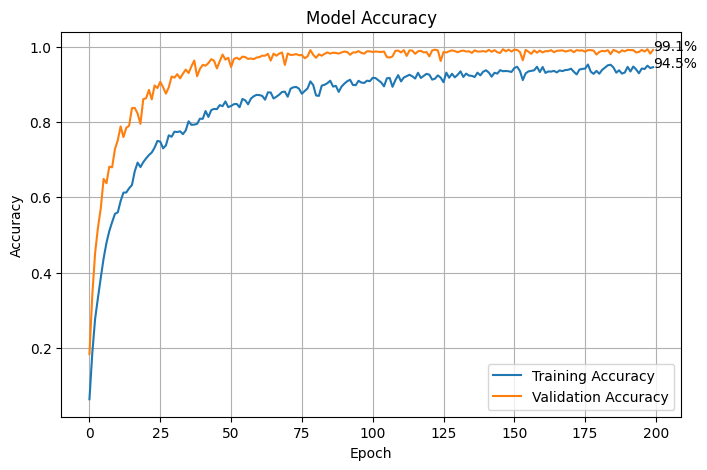

In [9]:
plt.figure(figsize=(8,5))

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

# Convert to percentage for printing
final_train = train_acc[-1] * 100
final_val = val_acc[-1] * 100

best_train = max(train_acc) * 100
best_val = max(val_acc) * 100

print(f"Final Training Accuracy: {final_train:.2f}%")
print(f"Final Validation Accuracy: {final_val:.2f}%")
print(f"Best Training Accuracy: {best_train:.2f}%")
print(f"Best Validation Accuracy: {best_val:.2f}%")

# Show % on graph (last epoch)
plt.text(len(train_acc)-1, train_acc[-1], f"{final_train:.1f}%")
plt.text(len(val_acc)-1, val_acc[-1], f"{final_val:.1f}%")

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.show()

Final Training Loss: 0.1727
Final Validation Loss: 0.0640
Best Training Loss: 0.1359
Best Validation Loss: 0.0501


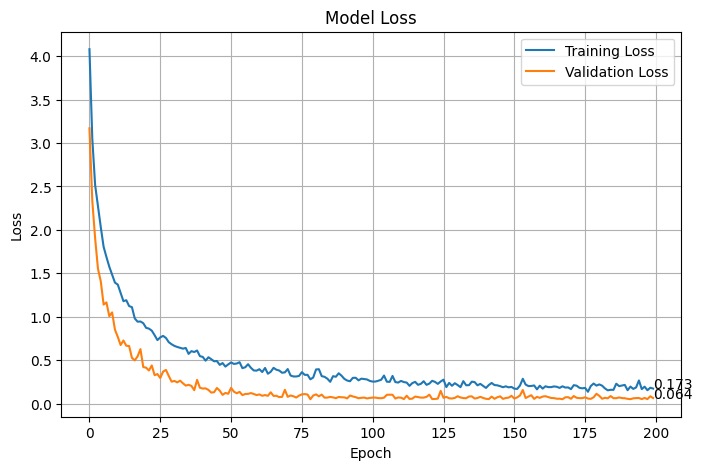

In [10]:
plt.figure(figsize=(8,5))

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

# Final loss
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Best (minimum) loss
best_train_loss = min(train_loss)
best_val_loss = min(val_loss)

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Best Training Loss: {best_train_loss:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

# Show values on graph (last epoch)
plt.text(len(train_loss)-1, train_loss[-1], f"{final_train_loss:.3f}")
plt.text(len(val_loss)-1, val_loss[-1], f"{final_val_loss:.3f}")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.show()

In [11]:

# Save model
model.save(MODEL_PATH)
print("Model saved:", MODEL_PATH)


Model saved: gem_Classification_Model.h5


In [12]:

# # Load model & classes
# model = load_model(MODEL_PATH)

# with open(CLASS_MAP_PATH, "r") as f:
#     class_map = json.load(f)

# class_names = list(class_map.keys())


In [13]:

# # Prediction function
# def predict_image(image_path):
#     img = Image.open(image_path).convert("RGB")
#     img = img.resize((IMG_SIZE, IMG_SIZE))
#     img_array = np.array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     preds = model.predict(img_array)
#     class_index = np.argmax(preds)
#     confidence = preds[0][class_index]

#     return class_names[class_index], confidence


In [14]:

# # Test prediction
# IMAGE_PATH = r"F:\FYP\code\dataset\GemStone\test\Ametrine\ametrine_22.jpg"

# label, conf = predict_image(IMAGE_PATH)
# print(f"Prediction: {label} ({conf*100:.2f}%)")


In [15]:
# def predict_with_chart(image_path):
#     img = Image.open(image_path).convert("RGB")
#     img = img.resize((IMG_SIZE, IMG_SIZE))
#     img_array = np.array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     preds = model.predict(img_array)[0]

#     # Bar chart
#     plt.figure(figsize=(8,4))
#     plt.bar(class_names, preds)
#     plt.xticks(rotation=45)
#     plt.ylabel("Confidence")
#     plt.title("Prediction Confidence per Class")
#     plt.show()

#     class_index = np.argmax(preds)
#     return class_names[class_index], preds[class_index]


In [16]:
# label, conf = predict_with_chart(IMAGE_PATH)
# print(f"Prediction: {label} ({conf*100:.2f}%)")